## Esercise 1

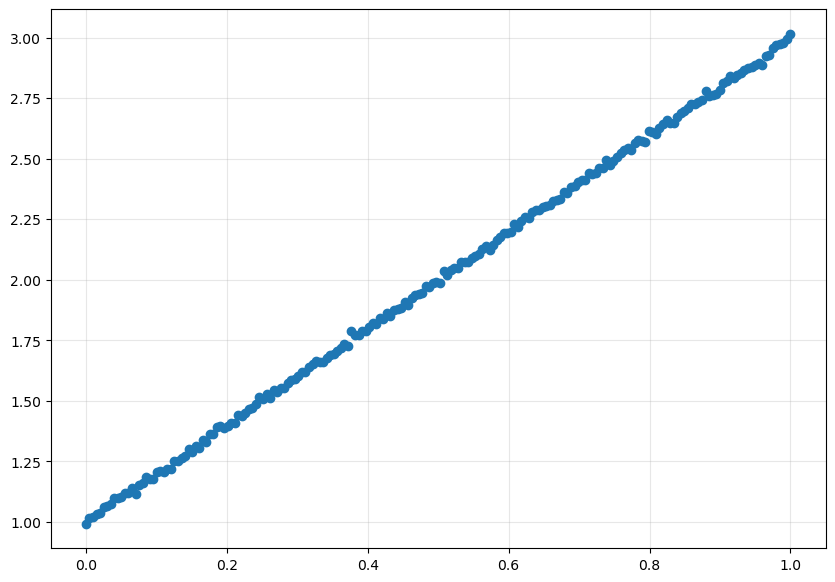

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

N = 200
X = np.linspace(0, 1, N) # equivalent to i/N
Y = 2 * X + 1 + np.random.normal(0, 0.01, size=X.shape)

# Visualize it
plt.figure(figsize=(10, 7))
plt.plot(X, Y, 'o')
plt.grid(alpha=0.3)
plt.show()

In [33]:
def l(Theta, X, Y):
    return np.mean(np.square(Theta[0] + Theta[1]*X - Y))  

def gradient(Theta, X, Y):
    N = len(X)
    g1 = 2 * np.mean(Theta[0] + Theta[1]*X - Y)
    g2 = 2 / N * np.dot(Theta[0] + Theta[1]*X - Y, X)
    return np.array([g1, g2])

def GD(l, grad_l, X, Y, theta_0, maxit, eta=1e-2, tolL=1e-6, tolTheta=1e-6):
    loss_history = []
    theta_history = []

    # GD step
    for k in range(maxit):
        theta = theta_0 - eta * grad_l(theta_0, X, Y)

        if(np.linalg.norm(grad_l(theta, X, Y))<tolL or (np.linalg.norm(theta-theta_0)<tolTheta)):
            break

        loss_history.append(l(theta, X, Y))
        theta_history.append(theta_0)

        theta_0 = theta
    return theta, k, loss_history, theta_history

def SGD(l, grad_l, X, Y, Theta0, lr=1e-2, batch_size=32, epochs=10):
    epoch_loss = []
    epoch_theta_history = []

    Theta = Theta0
    for epoch in range(epochs):
        shuffle_idx = np.random.permutation(len(X))
        N = len(X)

        for start in range(0, N, batch_size):
            batch_idx = shuffle_idx[start:start+batch_size]
            grad = grad_l(Theta, X[batch_idx], Y[batch_idx])
            Theta -= lr * grad

    
        epoch_loss.append(l(Theta, X, Y))
        epoch_theta_history.append(Theta.copy())

    return Theta, epoch, epoch_loss, epoch_theta_history

In [35]:
batch_sizes = [1,10,50,N]

results = pd.DataFrame([],columns=['model','batch_size', 'final_loss', 'epochs', 'Theta', 'epoch_loss', 'epoch_theta_history'])

Theta, epochs, epoch_loss, epoch_theta_history = GD(l, gradient, X, Y, np.zeros((2,)), maxit=1000, eta=1e-2, tolL=1e-6, tolTheta=1e-6)
final_loss = l(Theta, X, Y)
results.loc[len(results)] = ['GD', None, final_loss, epochs, Theta, epoch_loss, epoch_theta_history]

for batch_size in batch_sizes:
    Theta0 = np.zeros((2,))
    Theta, epochs, epoch_loss, epoch_theta_history = SGD(l, gradient, X, Y, Theta0, lr=1e-2, batch_size=batch_size, epochs=1000)
    final_loss = l(Theta, X, Y)
    results.loc[len(results)] = ['SGD', batch_size, final_loss, epochs, Theta, epoch_loss, epoch_theta_history]

display(results.sort_values(by='final_loss'))

,model,batch_size,final_loss,epochs,Theta,epoch_loss,epoch_theta_history
2,SGD,10,0.000099,999,"[1.0007491374168145, 1.9971338480217762]","[1.6152464437638219, 0.6401357338284884, 0.288...","[[0.6305469471714448, 0.3763105789418304], [1...."
1,SGD,1,0.000099,999,"[1.0008534122288966, 1.9973813396013997]","[0.06430925493307862, 0.03766232528333722, 0.0...","[[1.4630060648656187, 1.129186942524546], [1.3..."
3,SGD,50,0.000102,999,"[1.003785826607742, 1.9915907193549118]","[3.5479841921753645, 2.908117373647262, 2.3866...","[[0.15380481318537584, 0.09017107265266319], [..."
0,GD,None,0.007824,999,"[1.161840138132343, 1.6964756123568845]","[4.121639321922833, 3.920490231413971, 3.72939...","[[0.0, 0.0], [0.03998772288423061, 0.023355933..."
4,SGD,200,0.007824,999,"[1.161840138132343, 1.6964756123568845]","[4.121639321922833, 3.920490231413971, 3.72939...","[[0.03998772288423061, 0.023355933307853075], ..."


In [ ]:
batch_sizes = [1,10,50,N]

results = pd.DataFrame([],columns=['batch_size', 'final_loss', 'epochs', 'Theta', 'epoch_loss', 'epoch_theta_history'])
for batch_size in batch_sizes:
    Theta0 = np.zeros((2,))
    Theta, epochs, epoch_loss, epoch_theta_history = SGD(l, gradient, X, Y, Theta0, lr=1e-2, batch_size=batch_size, epochs=1000)
    final_loss = l(Theta, X, Y)
    results.loc[len(results)] = [batch_size, final_loss, epochs, Theta, epoch_loss, epoch_theta_history]

display(results.sort_values(by='final_loss'))

,batch_size,final_loss,epochs,Theta,epoch_loss,epoch_theta_history
1,10,0.000085,999,"[0.9989350157727234, 2.0013461088456364]","[1.6183920838276276, 0.6420773258142684, 0.288...","[[0.6298299199037363, 0.3765044557234348], [1...."
0,1,0.000085,999,"[0.9992760288664476, 2.00132195305034]","[0.06900555238000115, 0.04113156307498599, 0.0...","[[1.4788015382702075, 1.1025866726394375], [1...."
2,50,0.000088,999,"[1.0019622782119806, 1.995766580128819]","[3.5502303415926146, 2.9103384436684974, 2.388...","[[0.15376357326393508, 0.0902438029954543], [0..."
3,200,0.007865,999,"[1.1605705040821674, 1.699601129510411]","[4.123971806118748, 3.9227422011791155, 3.7315...","[[0.03999282786695151, 0.023365540532194626], ..."


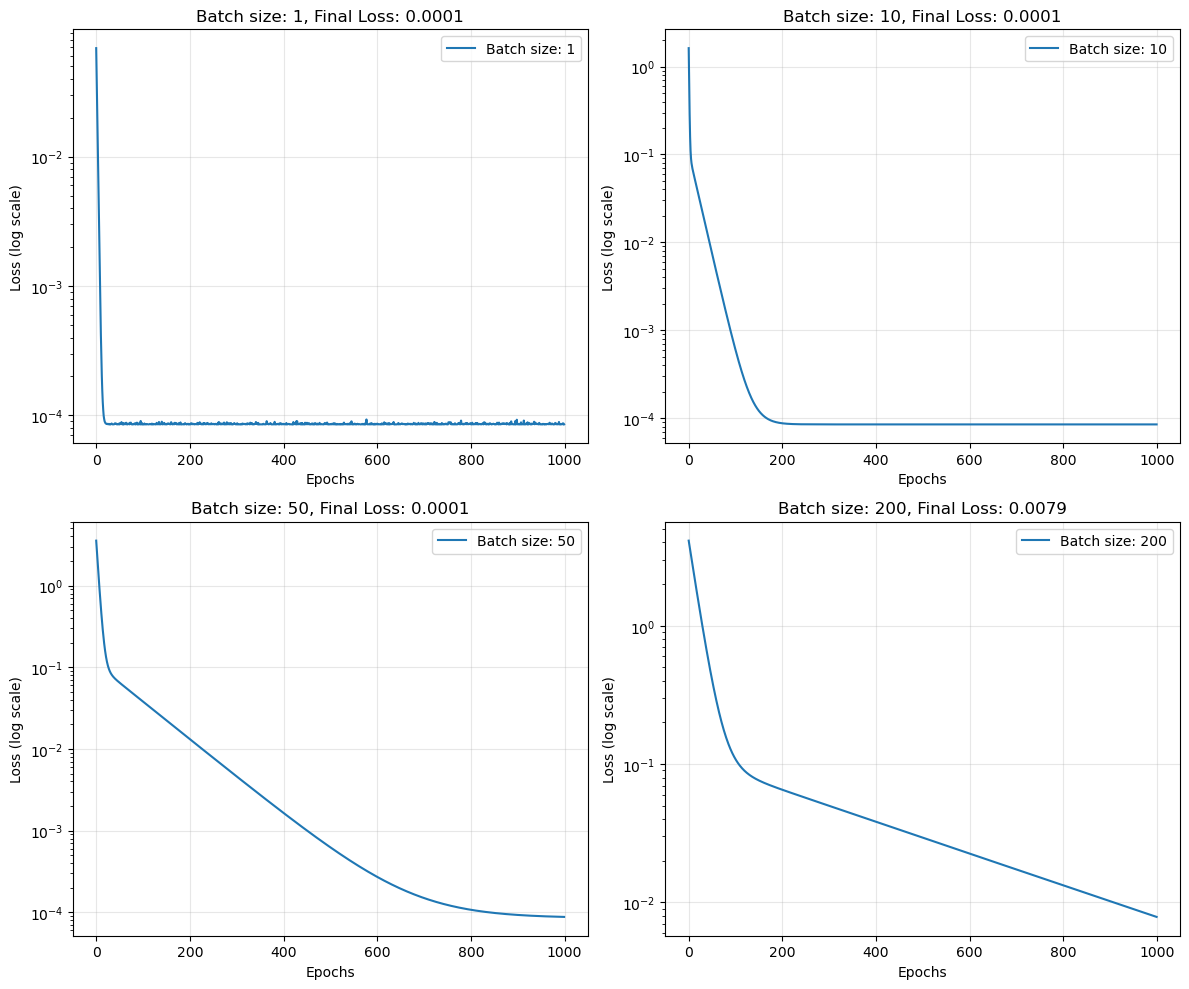

In [ ]:
n_plots = len(results)
n_cols = 2
n_rows = (n_plots + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten()
for index, row in results.iterrows():
    axes[index].plot(row['epoch_loss'], label=f"Batch size: {row['batch_size']}")
    axes[index].set_yscale('log')
    axes[index].set_xlabel("Epochs")
    axes[index].set_ylabel("Loss (log scale)")
    axes[index].legend()
    axes[index].grid(alpha=0.3)
    axes[index].set_title(f"Batch size: {row['batch_size']}, Final Loss: {row['final_loss']:.4f}")

plt.tight_layout()
plt.show()

In [ ]:
def loss_levelsets(X_data, Y_data, theta_0_lim=(0.5,1.5), theta_1_lim=(1.5,2.5), ngrid=400, 
                   ncontours=12, title=None):
    theta_0_vals = np.linspace(theta_0_lim[0], theta_0_lim[1], ngrid)
    theta_1_vals = np.linspace(theta_1_lim[0], theta_1_lim[1], ngrid)
    Theta0_grid, Theta1_grid = np.meshgrid(theta_0_vals, theta_1_vals)
    
    Z = np.mean((Theta0_grid[:,:,np.newaxis] + Theta1_grid[:,:,np.newaxis] * X_data - Y_data)**2, axis=2)
    
    cs = plt.contour(Theta0_grid, Theta1_grid, Z, levels=ncontours)
    plt.clabel(cs, inline=True, fontsize=8)
    plt.axhline(0, lw=0.5, color='k')
    plt.axvline(0, lw=0.5, color='k')
    plt.gca().set_aspect('equal', 'box')
    if title:
        plt.title(title)
    plt.xlabel(r'$\theta_0$ (bias)')
    plt.ylabel(r'$\theta_1$ (slope)')
    plt.grid(alpha=0.2)

    # ensure axis bounds are set so subsequent plotting is clipped to these limits
    plt.xlim(theta_0_lim)
    plt.ylim(theta_1_lim)

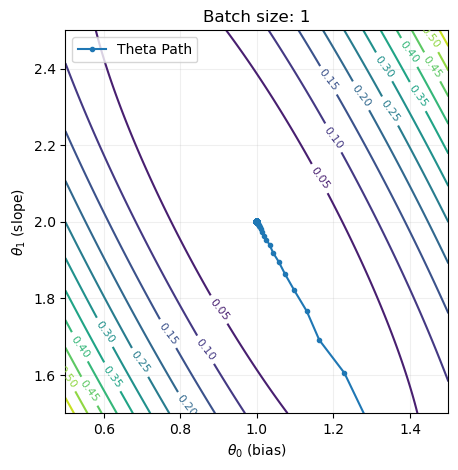

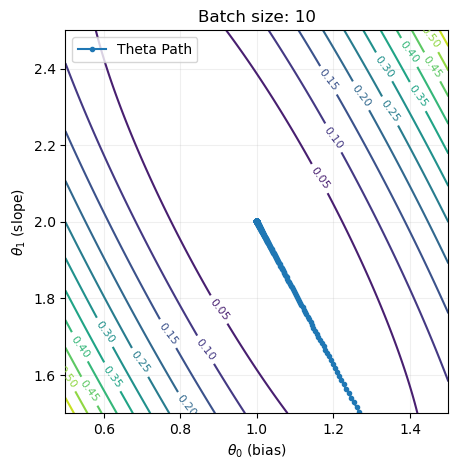

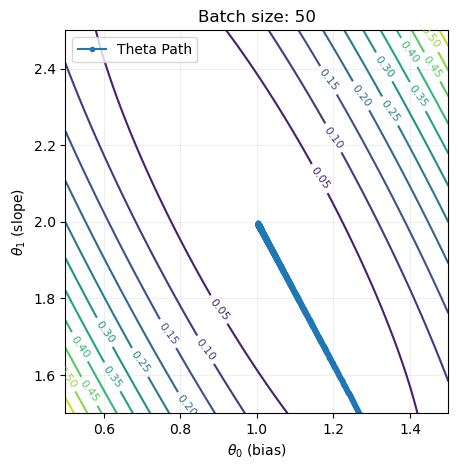

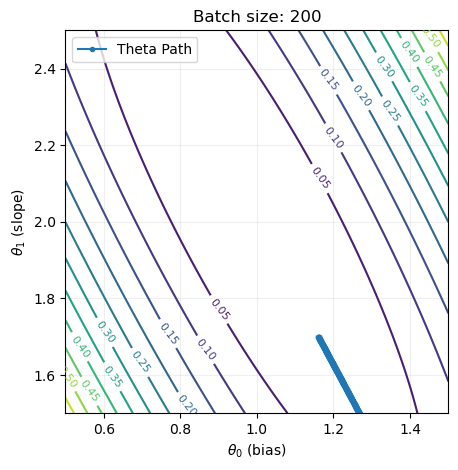

In [ ]:
# plot epoch theta history
for index, row in results.iterrows():
    loss_levelsets(X, Y, title=f"Batch size: {row['batch_size']}")
    plt.plot(
        [theta[0] for theta in row['epoch_theta_history']],
        [theta[1] for theta in row['epoch_theta_history']],
        '-o', markersize=3, label='Theta Path'
    )
    plt.legend()
    plt.tight_layout()
    plt.show()


## Ex 2

In [ ]:
fixed_theta = np.array([1.0, 2.0])

batch_sizes = [1,5,20,N]

monte_carlo_variance_estimates = pd.DataFrame([], columns=['batch_size', 'grad_mean', 'grad_variance'])

for batch_size in batch_sizes:
    n_of_iterations = 100
    grads = []
    for i in range(n_of_iterations):
        shuffle_idx = np.random.permutation(len(X))   
        batch_idx = shuffle_idx[:batch_size]
        grad = gradient(fixed_theta, X[batch_idx], Y[batch_idx])
        grads.append(grad)
    grads = np.array(grads)
    grad_mean =  1/n_of_iterations * np.sum(grads, axis=0)  
    grad_variance = 1/n_of_iterations * np.sum(np.linalg.norm(grads - grad_mean, axis=1)**2) 
    monte_carlo_variance_estimates.loc[len(monte_carlo_variance_estimates)] = [batch_size, grad_mean, grad_variance]

display(monte_carlo_variance_estimates.sort_values(by='grad_variance', ascending=False))

,batch_size,grad_mean,grad_variance
0,1,"[-0.0005740813799560885, -0.0007667265018229922]",4.617993e-04
1,5,"[0.00035472420847864396, -0.00019262380455016944]",6.066624e-05
2,20,"[0.0007442976403287285, 0.00025515370705597626]",2.232172e-05
3,200,"[0.000717213304849043, 0.00012936386596459798]",2.134183e-37


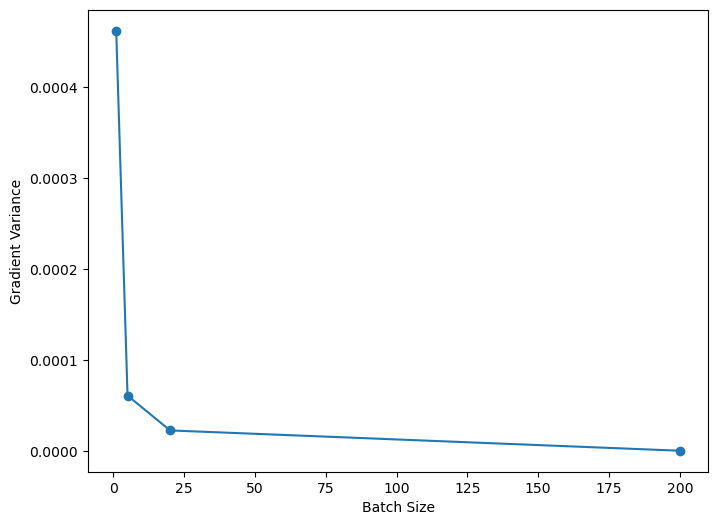

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(monte_carlo_variance_estimates['batch_size'], monte_carlo_variance_estimates['grad_variance'], '-o')
plt.xlabel("Batch Size")
plt.ylabel("Gradient Variance")
plt.show()

## Ex 3

In [ ]:
def l(Theta):
    return (1 - Theta[0])**2 + 10 * (Theta[1] - Theta[0]**2)**2

def gradient(Theta):
    g1 = -2 * (1 - Theta[0]) - 40 * Theta[0] * (Theta[1] - Theta[0]**2)
    g2 = 20 * (Theta[1] - Theta[0]**2)
    return np.array([g1, g2])

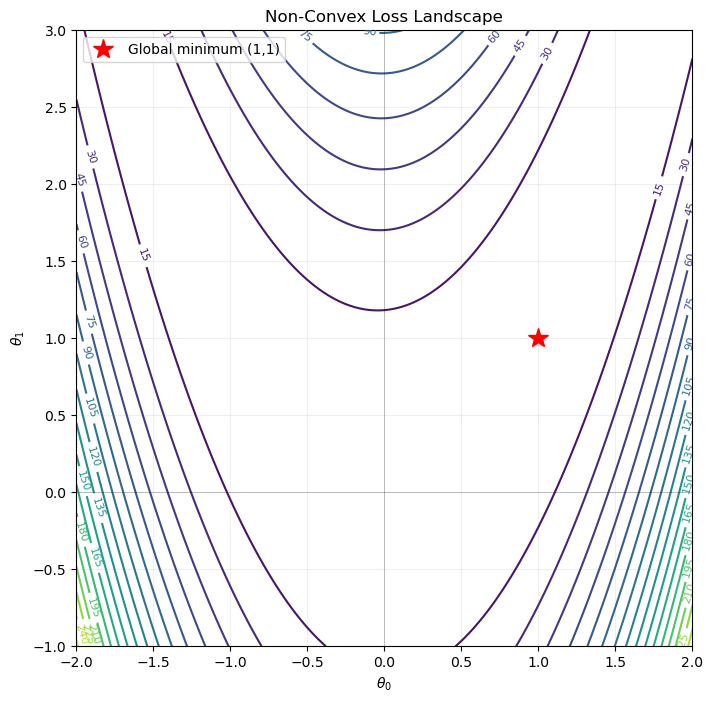

In [ ]:
# Visualize the loss landscape
def plot_nonconvex_levelsets(theta_0_lim=(-2, 2), theta_1_lim=(-1, 3), ngrid=400, ncontours=20, title=None):
    theta_0_vals = np.linspace(theta_0_lim[0], theta_0_lim[1], ngrid)
    theta_1_vals = np.linspace(theta_1_lim[0], theta_1_lim[1], ngrid)
    Theta0_grid, Theta1_grid = np.meshgrid(theta_0_vals, theta_1_vals)
    
    # Compute loss for each grid point
    Z = (1 - Theta0_grid)**2 + 10 * (Theta1_grid - Theta0_grid**2)**2
    
    cs = plt.contour(Theta0_grid, Theta1_grid, Z, levels=ncontours, cmap='viridis')
    plt.clabel(cs, inline=True, fontsize=8)
    
    # Mark the global minimum at (1, 1)
    plt.plot(1, 1, 'r*', markersize=15, label='Global minimum (1,1)')
    
    plt.axhline(0, lw=0.5, color='k', alpha=0.3)
    plt.axvline(0, lw=0.5, color='k', alpha=0.3)
    plt.gca().set_aspect('equal', 'box')
    if title:
        plt.title(title)
    plt.xlabel(r'$\theta_0$')
    plt.ylabel(r'$\theta_1$')
    plt.grid(alpha=0.2)
    plt.xlim(theta_0_lim)
    plt.ylim(theta_1_lim)
    plt.legend()

# Plot the landscape
plt.figure(figsize=(10, 8))
plot_nonconvex_levelsets(title='Non-Convex Loss Landscape')
plt.show()

In [ ]:
def SGD_with_noise(L, grad_L, theta_0, lr=1e-3, noise_level=0.1, epochs=1000):
    """
    SGD with simulated gradient noise.
    
    At each iteration, the gradient batch is:
        g_batch = grad_L(theta) + N(0, noise_level^2 * I)
    """
    theta = theta_0.copy()
    theta_history = [theta.copy()]
    loss_history = [L(theta)]
    
    for epoch in range(epochs):
        # Compute true gradient
        g_true = grad_L(theta)
        
        # Add Gaussian noise to simulate stochastic gradient
        noise = np.random.normal(0, noise_level, size=theta.shape)
        g_batch = g_true + noise
        
        # SGD update
        theta = theta - lr * g_batch
        
        theta_history.append(theta.copy())
        loss_history.append(L(theta))

        if np.linalg.norm(theta) > 1e5:
            break
    
    return theta, theta_history, loss_history

In [ ]:
from sklearn.model_selection import ParameterGrid

starting_theta = np.array([0.0, 0.0])
etas = [0.1, 0.01, 0.001, 0.0001]
noise_levels = [0.05, 0.1, 0.5, 1.0]

param_grid = ParameterGrid({'eta': etas, 'noise_level': noise_levels})
configurations = list(param_grid)

In [ ]:
SGD_simulations = pd.DataFrame([], columns=['eta', 'noise_level', 'final_theta', 'final_loss', 'theta_history', 'loss_history'])

for config in configurations:
    eta = config['eta']
    noise_level = config['noise_level']
    
    theta0 = np.array([0.0, 0.0])
    theta_final, theta_history, loss_history = SGD_with_noise(
        L=l, grad_L=gradient, theta_0=theta0, lr=eta, noise_level=noise_level, epochs=5000
    )
    
    final_loss = l(theta_final)
    SGD_simulations.loc[len(SGD_simulations)] = [eta, noise_level, theta_final, final_loss, theta_history, loss_history]

display(SGD_simulations[['eta', 'noise_level', 'final_loss','final_theta']].sort_values(by='final_loss'))

,eta,noise_level,final_loss,final_theta
4,0.0100,0.05,1.323187e-06,"[0.9997153910279963, 0.9990784166208407]"
5,0.0100,0.10,3.604988e-05,"[0.9940141478527497, 0.9882122669002851]"
11,0.0010,1.00,4.996426e-04,"[0.9777330720677161, 0.9553433700535946]"
6,0.0100,0.50,2.097007e-03,"[0.997394648544898, 1.0092536750394225]"
8,0.0010,0.05,2.134576e-03,"[0.9541896288475177, 0.9085808438575603]"
9,0.0010,0.10,2.248916e-03,"[0.9535204538506729, 0.906225216639925]"
10,0.0010,0.50,3.550743e-03,"[0.9406134410608271, 0.8832051185092352]"
7,0.0100,1.00,1.727118e-02,"[1.0185113753106338, 1.078509688994741]"
15,0.0001,1.00,2.441906e-01,"[0.5118160070170559, 0.23773384094218672]"
14,0.0001,0.50,2.459781e-01,"[0.51081702892245, 0.23509193715549126]"


In [ ]:
SGD_simulations = pd.DataFrame([], columns=['eta', 'noise_level', 'final_theta', 'final_loss', 'theta_history', 'loss_history'])

for config in configurations:
    eta = config['eta']
    noise_level = config['noise_level']
    
    theta0 = np.array([0.0, 0.0])
    theta_final, theta_history, loss_history = SGD_with_noise(
        L=l, grad_L=gradient, theta_0=theta0, lr=eta, noise_level=noise_level, epochs=5000
    )
    
    final_loss = l(theta_final)
    SGD_simulations.loc[len(SGD_simulations)] = [eta, noise_level, theta_final, final_loss, theta_history, loss_history]

display(SGD_simulations[['eta', 'noise_level', 'final_loss','final_theta']].sort_values(by='final_loss'))

,eta,noise_level,final_loss,final_theta
4,0.0100,0.05,1.929190e-05,"[0.996036963366901, 0.9926884847278049]"
5,0.0100,0.10,4.558840e-05,"[1.004896669907717, 1.0083472483728724]"
11,0.0010,1.00,2.837820e-04,"[0.9935044087190108, 0.982135836827587]"
10,0.0010,0.50,1.097762e-03,"[0.9689625901407992, 0.9352218724706468]"
8,0.0010,0.05,2.054529e-03,"[0.9550185519335281, 0.9102941268777889]"
9,0.0010,0.10,2.096174e-03,"[0.9544857474429731, 0.9094737358489486]"
6,0.0100,0.50,4.986802e-03,"[0.965230526979669, 0.9511067554424477]"
7,0.0100,1.00,5.698257e-03,"[1.0750771632696832, 1.1533074374265986]"
15,0.0001,1.00,2.443828e-01,"[0.5118001993201062, 0.23735541598872378]"
13,0.0001,0.10,2.465900e-01,"[0.5098737181444645, 0.23473982991100464]"


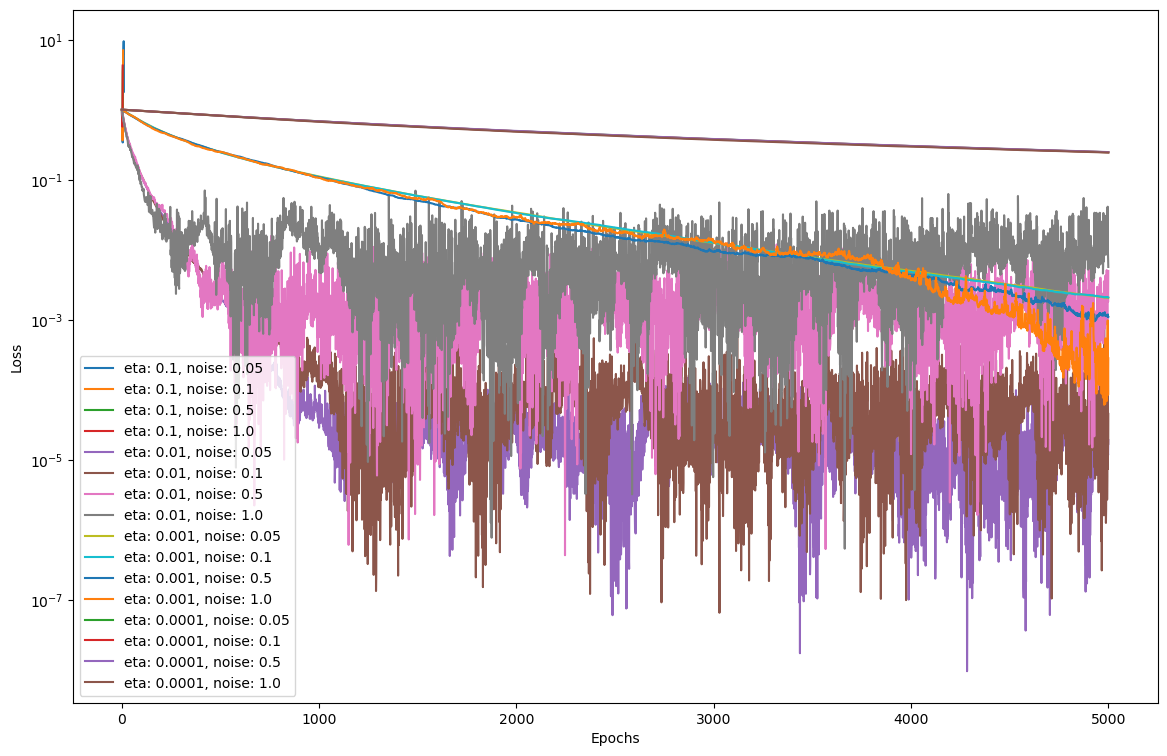

In [41]:
# Plot loss
plt.figure(figsize=(14, 9))
for index, row in SGD_simulations.iterrows():
    loss = np.array(row['loss_history'])
    idx = np.where(loss < 1e1)[0]
    if idx.size:
        plt.plot(idx, loss[idx], label=f"eta: {row['eta']}, noise: {row['noise_level']}")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.yscale('log')
plt.legend()
plt.show()
# ...existing code...

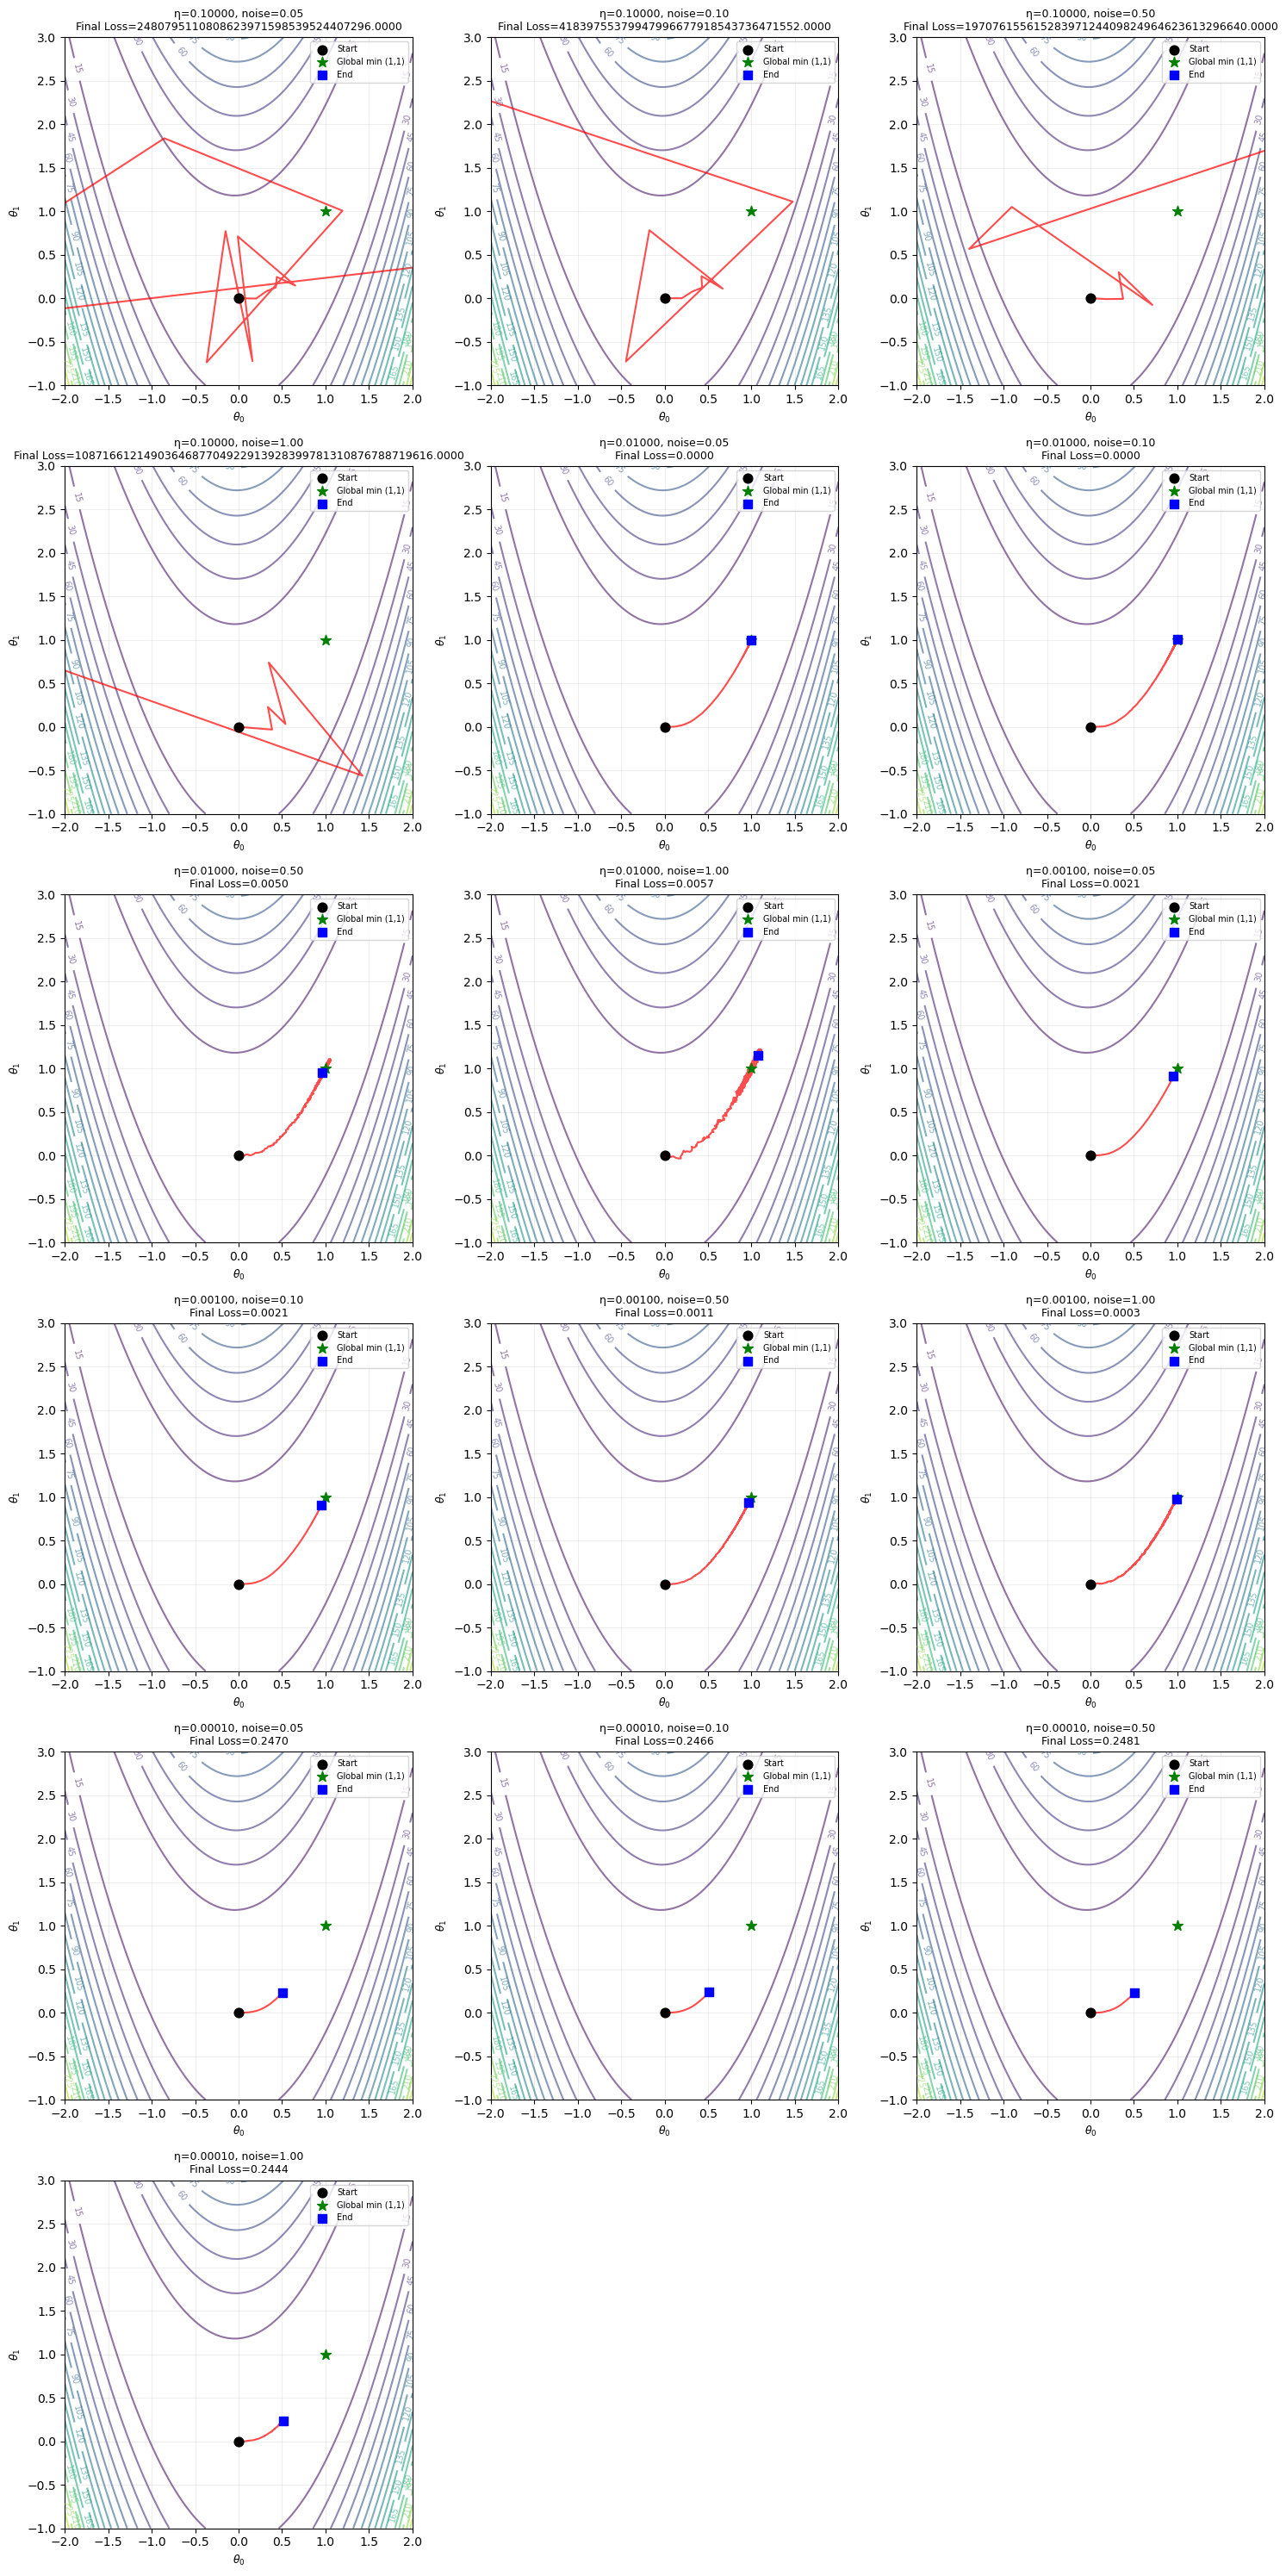

In [ ]:
# Plot trajectories for all configurations
n_plots = len(configurations)
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for ax, (idx, row) in zip(axes, SGD_simulations.iterrows()):
    eta = row['eta']
    noise_level = row['noise_level']
    theta_history = np.array(row['theta_history'])
    
    # Draw level sets
    xs = np.linspace(-2, 2, 400)
    ys = np.linspace(-1, 3, 400)
    X_grid, Y_grid = np.meshgrid(xs, ys)
    Z = (1 - X_grid)**2 + 10 * (Y_grid - X_grid**2)**2
    cs = ax.contour(X_grid, Y_grid, Z, levels=20, cmap='viridis', alpha=0.6)
    ax.clabel(cs, inline=True, fontsize=7)
    
    # Plot trajectory
    ax.plot(theta_history[:, 0], theta_history[:, 1], 'r-', alpha=0.7, linewidth=1.5)
    ax.scatter(theta_history[0, 0], theta_history[0, 1], color='black', s=60, marker='o', zorder=5, label='Start')
    ax.scatter(1, 1, color='green', s=80, marker='*', zorder=5, label='Global min (1,1)')
    ax.scatter(theta_history[-1, 0], theta_history[-1, 1], color='blue', s=60, marker='s', zorder=5, label='End')
    
    ax.legend(loc='upper right', fontsize=7)
    ax.set_title(f'η={eta:.5f}, noise={noise_level:.2f}\nFinal Loss={row["final_loss"]:.4f}', fontsize=9)
    ax.set_xlabel(r'$\theta_0$', fontsize=9)
    ax.set_ylabel(r'$\theta_1$', fontsize=9)
    ax.grid(alpha=0.2)
    ax.set_aspect('equal', 'box')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1, 3)

# Hide empty subplots
for ax in axes[n_plots:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

# Ex 4

In [ ]:
df0 = pd.read_csv('./insurance.csv')
df0.shape

(1338, 7)

In [ ]:
df0.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df = df0[['age','bmi','children']]
Y = df0['charges'].to_numpy()

df.head()

,age,bmi,children
0,19,27.900,0
1,18,33.770,1
2,28,33.000,3
3,33,22.705,0
4,32,28.880,0


In [ ]:
X = df.to_numpy()
X = (X - X.mean(axis=0)) / X.std(axis=0) 
X = np.hstack([np.ones((X.shape[0], 1)), X]) 
Y = (Y - Y.mean()) / Y.std()

In [ ]:
def l(Theta, X_data=X, Y_data=Y):
    N = len(Y_data)
    predictions = X_data @ Theta
    return (1/N) * np.sum((predictions - Y_data)**2)

def gradient(Theta, X_data=X, Y_data=Y):
    N = len(Y_data)
    predictions = X_data @ Theta
    errors = predictions - Y_data
    grad = (2/N) * (X_data.T @ errors)
    return grad

def SGD(l, grad_l, X, Y, Theta0, lr=1e-2, batch_size=32, epochs=10):
    epoch_loss = []
    epoch_theta_history = []
    epoch_l2_norm_history = []

    Theta = Theta0
    for epoch in range(epochs):
        shuffle_idx = np.random.permutation(len(X))
        N = len(X)

        for start in range(0, N, batch_size):
            batch_idx = shuffle_idx[start:start+batch_size]
            grad = grad_l(Theta, X[batch_idx], Y[batch_idx])
            Theta -= lr * grad

    
        epoch_loss.append(l(Theta, X, Y))
        epoch_theta_history.append(Theta.copy())
        epoch_l2_norm_history.append(np.linalg.norm(Theta))

    return Theta, epoch, epoch_loss, epoch_theta_history, epoch_l2_norm_history

In [ ]:
N = X.shape[0]

batch_sizes = [1,10,50,N]

results = pd.DataFrame([],columns=['batch_size', 'final_loss', 'epochs', 'Theta', 'L2_norm_history','epoch_loss', 'epoch_theta_history'])
for batch_size in batch_sizes:
    Theta0 = np.zeros((X.shape[1],))
    Theta, epochs, epoch_loss, epoch_theta_history, epoch_l2_norm_history = SGD(l, gradient, X, Y, Theta0, lr=1e-2, batch_size=batch_size, epochs=1000)
    final_loss = l(Theta, X, Y)
    results.loc[len(results)] = [batch_size, final_loss, epochs, Theta, epoch_l2_norm_history, epoch_loss, epoch_theta_history]

In [ ]:
display(results[['batch_size','final_loss','Theta']].sort_values(by='final_loss').style.format({'final_loss':'{:.6f}','Theta':lambda x: np.array2string(x, precision=4)}))

,batch_size,final_loss,Theta
3,1338,0.879902,[1.4190e-17 2.7844e-01 1.6723e-01 5.4040e-02]
2,50,0.879941,[0.004 0.2818 0.1701 0.0529]
1,10,0.880388,[0.0103 0.2705 0.1518 0.0472]
0,1,0.910870,[-0.0172 0.294 0.0014 -0.0037]


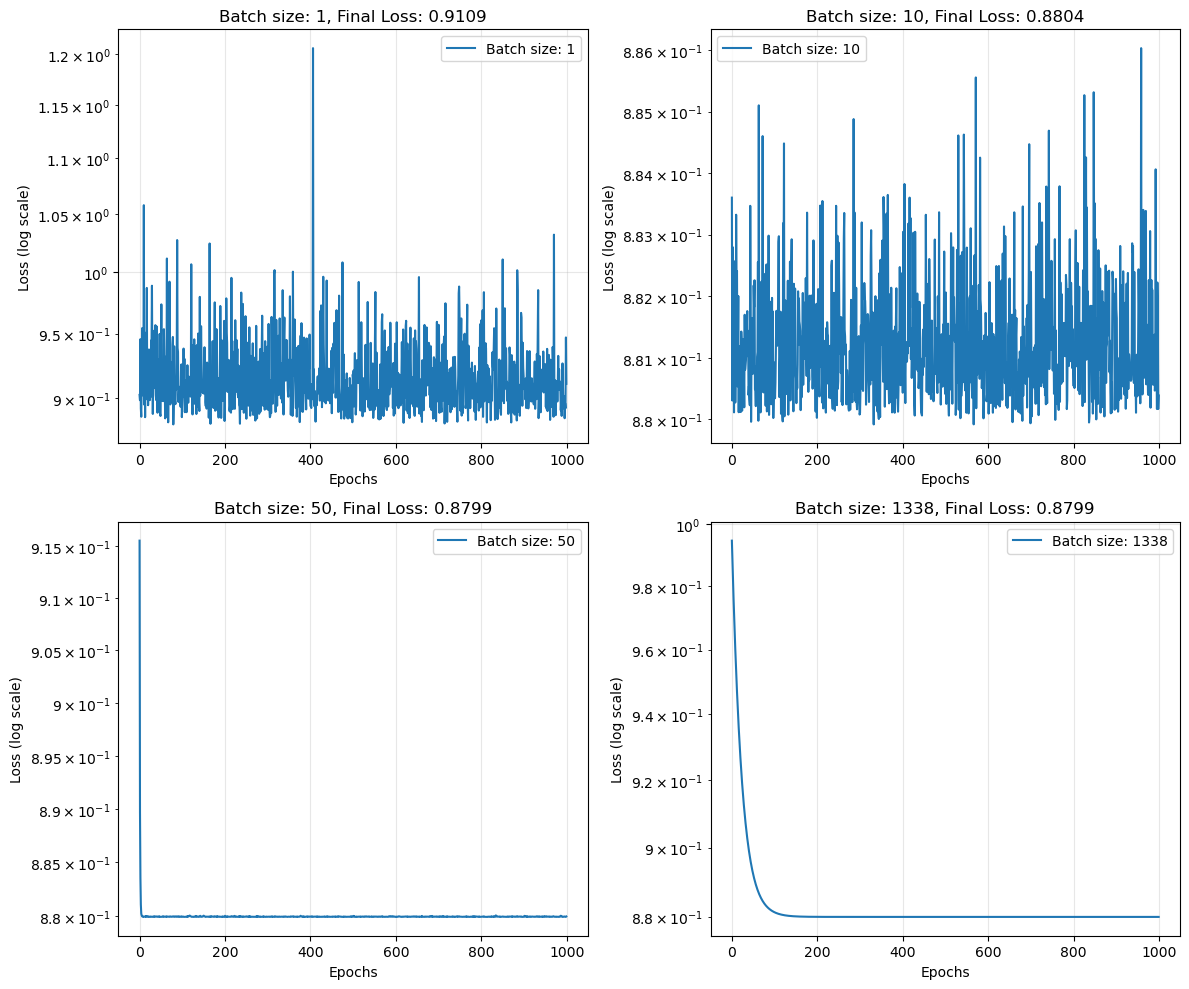

In [ ]:
n_plots = len(results)
n_cols = 2
n_rows = (n_plots + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten()
for index, row in results.iterrows():
    axes[index].plot(row['epoch_loss'], label=f"Batch size: {row['batch_size']}")
    axes[index].set_yscale('log')
    axes[index].set_xlabel("Epochs")
    axes[index].set_ylabel("Loss (log scale)")
    axes[index].legend()
    axes[index].grid(alpha=0.3)
    axes[index].set_title(f"Batch size: {row['batch_size']}, Final Loss: {row['final_loss']:.4f}")

plt.tight_layout()
plt.show()

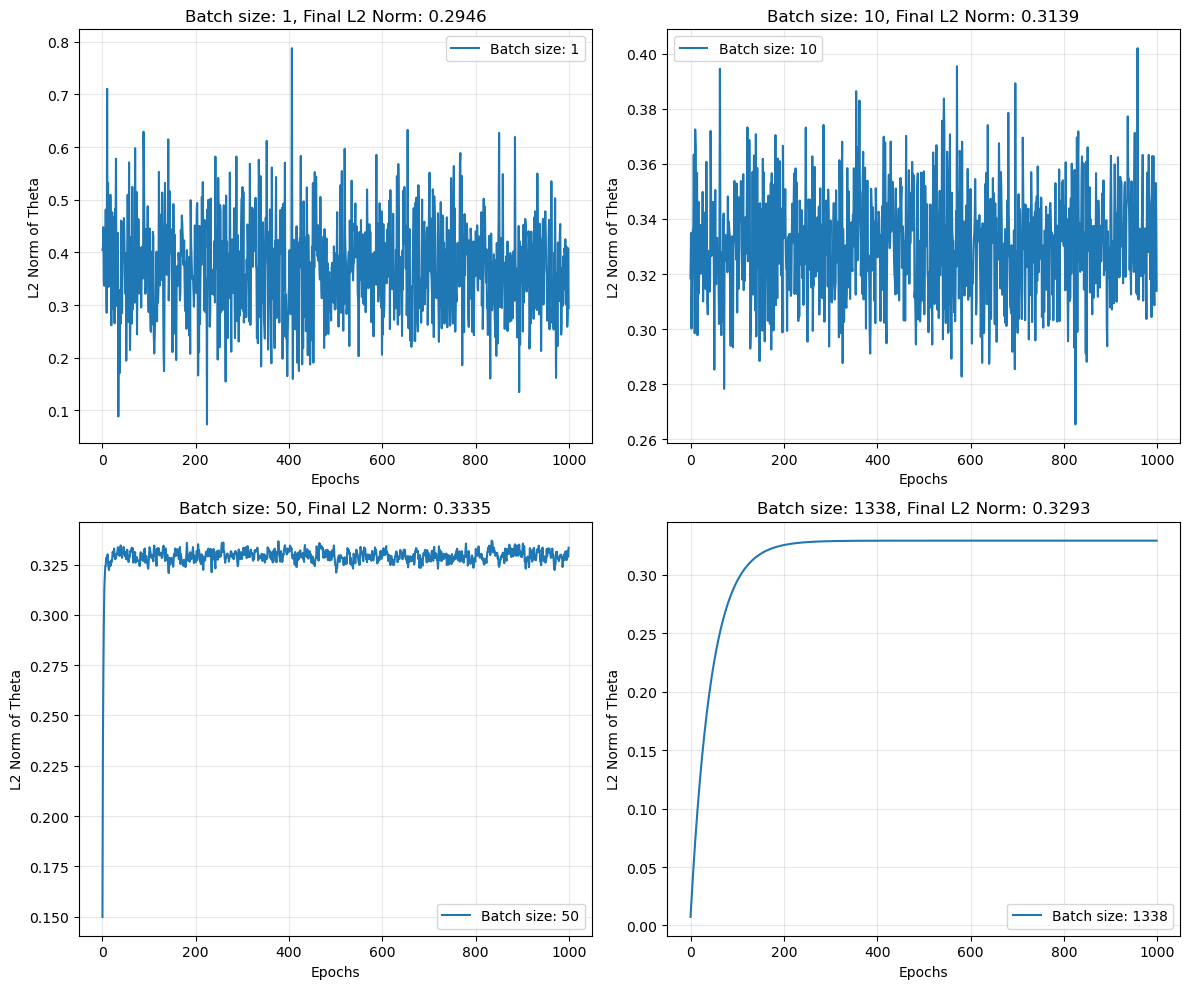

In [ ]:
# print the L2 norm history for each batch size
n_plots = len(results)
n_cols = 2
n_rows = (n_plots + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 *n_rows))
axes = axes.flatten()
for index, row in results.iterrows():
    axes[index].plot(row['L2_norm_history'], label=f"Batch size: {row['batch_size']}")
    axes[index].set_xlabel("Epochs")
    axes[index].set_ylabel("L2 Norm of Theta")
    axes[index].legend()
    axes[index].grid(alpha=0.3)
    axes[index].set_title(f"Batch size: {row['batch_size']}, Final L2 Norm: {row['L2_norm_history'][-1]:.4f}")
plt.tight_layout()
plt.show()